Data ready! Train size: 241, Test size: 61

⚡ Baseline Accuracy (Logistic Regression): 80.33%

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



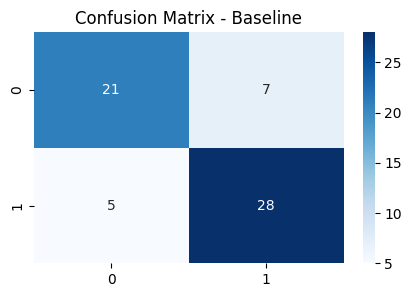


Training Improved Model (Random Forest)...
✅ Best Parameters: {'max_depth': None, 'n_estimators': 50}
🚀 Improved Accuracy (Random Forest): 73.77%
📈 10-Fold CV Mean Accuracy: 81.10%

=== Final Comparison ===


,Model,Accuracy
0,Logistic Regression (Baseline),0.803279
1,Random Forest (Improved),0.737705


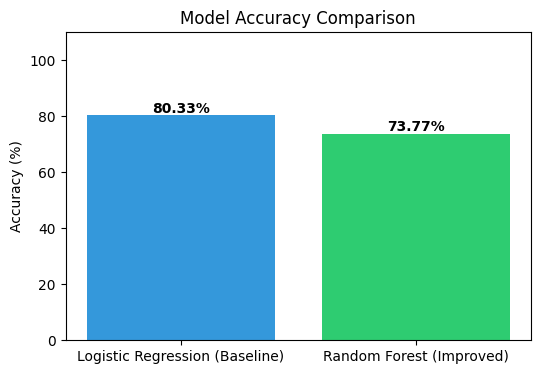

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# STEP 1 & 2: Data Load aur Preprocessing
# ==========================================
# Corrected file path based on kernel state
df = pd.read_csv('/content/heart.csv')

df = df.drop_duplicates()
X = df.drop('target', axis=1)
y = df['target']

specified_vars = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data ready! Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# ==========================================
# STEP 3 & 4: Baseline Model (Logistic Regression)
# ==========================================
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"\n⚡ Baseline Accuracy (Logistic Regression): {baseline_accuracy*100:.2f}%")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_baseline))

plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred_baseline), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Baseline')
plt.show()

# ==========================================
# STEP 5: Model Improvement (Random Forest + GridSearch)
# ==========================================
print("\nTraining Improved Model (Random Forest)...")
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

improved_model = grid_search.best_estimator_
y_pred_improved = improved_model.predict(X_test)
improved_accuracy = accuracy_score(y_test, y_pred_improved)

print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"🚀 Improved Accuracy (Random Forest): {improved_accuracy*100:.2f}%")

cv_scores = cross_val_score(improved_model, X_scaled, y, cv=10)
print(f"📈 10-Fold CV Mean Accuracy: {cv_scores.mean()*100:.2f}%")

# ==========================================
# STEP 6: Results & Chart
# ==========================================
results = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'Random Forest (Improved)'],
    'Accuracy': [baseline_accuracy, improved_accuracy]
})
print("\n=== Final Comparison ===")
display(results)

plt.figure(figsize=(6, 4))
bars = plt.bar(results['Model'], results['Accuracy'] * 100, color=['#3498db', '#2ecc71'])
plt.ylim(0, 110)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}%', ha='center', fontweight='bold')
plt.show()